In [2]:
#import all needed libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import dataloader
import torch.nn as nn

In [11]:
#Variables
batch_size=64
num_classes=10
img_size=28
num_channels=1
patch_size=7
patch_num=(img_size/patch_size)*(img_size/patch_size)
attention_head=4
embed_dim=16
transformer_blocks=4
mlp_nodes=64
mlp_dim = 16
transformer_units = 1
num_heads = 1

In [4]:
#transformation of PIL data into tensor format
transfromation_operation=transforms.Compose([transforms.ToTensor()])

In [5]:
train_dataset= torchvision.datasets.MNIST(root='./data',train=True, download=True,transform=transfromation_operation)
vald_dataset= torchvision.datasets.MNIST(root='./data',train=False, download=True,transform=transfromation_operation)


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.82MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.97MB/s]


In [35]:
train_data=dataloader.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
vald_data=dataloader.DataLoader(vald_dataset,batch_size=batch_size,shuffle=True)

In [30]:
#class for PatchEmbedding - Part 1
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed=nn.Conv2d(num_channels,embed_dim,kernel_size=patch_size,stride=patch_size)

    def forward(self,x):
        x=self.embed(x)
        x=x.flatten(2)
        x=x.transpose(1,2)
        return x

In [19]:
#class for Transfomrer encoder - Part 2
#Layer_normalisation
#Multi head attention
#Layer Normalisation
#residuals
#MLP - activation function
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1=nn.LayerNorm(embed_dim)
        self.self_attention=nn.MultiheadAttention(embed_dim,num_heads,batch_first=True)
        self.layer_norm2=nn.LayerNorm(embed_dim)
        self.multi_layer_perceptron=nn.Sequential(
            nn.Linear(embed_dim,mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim,embed_dim)
        )

    def forward(self,x):
        residual_1=x
        attention_output=self.self_attention(self.layer_norm1(x),self.layer_norm1(x),self.layer_norm1(x))[0]
        x=attention_output+residual_1
        residual_2=x
        mlp_output=self.multi_layer_perceptron(self.layer_norm2(x))
        x=mlp_output+residual_2
        return x


In [24]:
#class for MLP head for classifiaction - Part 3
class MLP_head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layernorm1=nn.LayerNorm(embed_dim)
        self.MLP_head=nn.Sequential(
            nn.Linear(embed_dim,num_classes)
        )

    def forward(self,x):
        x=x[:,0]
        x=self.layernorm1(x)
        x=self.MLP_head(x)
        return x

In [25]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding=PatchEmbedding()
        self.cls_token=nn.Parameter(torch.randn(1,1,embed_dim))
        self.pos_embed=nn.Parameter(torch.randn(1,(img_size//patch_size)**2+1,embed_dim))
        self.transformer_layers=nn.Sequential(*[TransformerEncoder() for _ in range(transformer_units)])
        self.mlp_head=nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim,num_classes)
        )

    def forward(self,x):
        x=self.patch_embedding(x)
        B=x.size(0)
        cls_tokens=self.cls_token.expand(B,-1,-1)
        x=torch.cat((cls_tokens,x),dim=1)
        x=x+self.pos_embed
        x=self.transformer_layers(x)
        x=x[:,0]
        x=self.mlp_head(x)
        return x

In [26]:
#to print dims
images,labels =next(iter(train_data))
patch_embed=nn.Conv2d(num_channels,embed_dim,kernel_size=patch_size,stride=patch_size)
print(images.shape)
print(patch_embed(images).shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 16, 4, 4])


In [31]:

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=VisionTransformer().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
criterion=nn.CrossEntropyLoss()


In [39]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 0.1824, Accuracy = 95.31%
  Batch 101: Loss = 0.6121, Accuracy = 87.50%
  Batch 201: Loss = 0.1180, Accuracy = 95.31%
  Batch 301: Loss = 0.4584, Accuracy = 85.94%
  Batch 401: Loss = 0.3480, Accuracy = 89.06%
  Batch 501: Loss = 0.3373, Accuracy = 84.38%
  Batch 601: Loss = 0.2577, Accuracy = 90.62%
  Batch 701: Loss = 0.2519, Accuracy = 90.62%
  Batch 801: Loss = 0.2804, Accuracy = 85.94%
  Batch 901: Loss = 0.2864, Accuracy = 93.75%
==> Epoch 1 Summary: Total Loss = 320.9057, Accuracy = 89.08%

Epoch 2
  Batch   1: Loss = 0.3745, Accuracy = 85.94%
  Batch 101: Loss = 0.2808, Accuracy = 87.50%
  Batch 201: Loss = 0.2452, Accuracy = 89.06%
  Batch 301: Loss = 0.3902, Accuracy = 90.62%
  Batch 401: Loss = 0.2500, Accuracy = 92.19%
  Batch 501: Loss = 0.3522, Accuracy = 87.50%
  Batch 601: Loss = 0.3044, Accuracy = 92.19%
  Batch 701: Loss = 0.3454, Accuracy = 92.19%
  Batch 801: Loss = 0.2894, Accuracy = 92.19%
  Batch 901: Loss = 0.1889, Accuracy = 96.88%


In [40]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in vald_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 88.30%


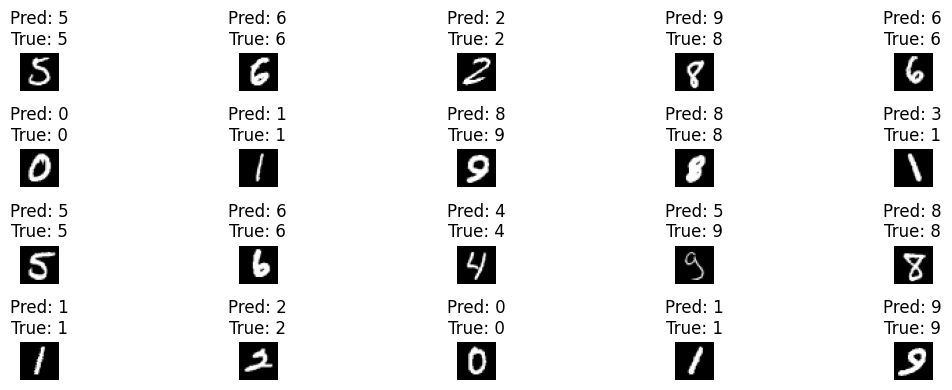

In [41]:
model.eval()
images, labels = next(iter(vald_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()